# E-Commerce Performance Analysis: Logistics Strategy & Seasonal Sales Impact

## Overview
This project aims to help with possible business decisions about the Brazilian e-commerce (2016-2018) dataset by Olist ([available on Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)). Throughout this project, we will start with an EDA, looking for the most sold items and categories with the most sales and revenue. At the end, we will statistically study the following hypotheses:

1- **Seasonal Sales Impact:** The statistical relevance of November (Black Friday) on total sales volume.

2- **Operational Logistics:** Do stores strategically inflate shipping deadlines?

These hypotheses will serve to answer some business problems, such as:

* **The Seasonal Impact:** Does the Black Friday (and it's associated promotions e.g. Black Week) truly generate a statistically significant increase in sales compared to the rest of the year?

* **The Logistics Dilemma:** Long delivery times protects the operation but might hurt checkout conversion rates and yield worse reviews on delays.

### Tech Stack & Methodology
* **Data Extraction & Aggregation:** SQLite via pandas.
* **Statistical & Predictive Modeling:** Python (`pandas`, `scipy.stats`, `statsmodels`).
  * *Method 1:* Ordinary Least Squares (OLS) Linear Regression with a temporal Dummy Variable for November (Black Friday impact).
  * *Method 2:* Right-tailed One-Sample t-Test (Logistics verification).

### Executive Summary & Key Insights
A high-level summary of the statistical findings and operational insights derived from this analysis:

* **Black Friday Performance:** The OLS linear regression model confirms that November IS **statistically significant** on the sales volume ($p = 0.005$). Controlling for the market's growth trend over time, the Black Friday month generates an average increase of **~2,535 additional orders** ($\beta = 2534.63$). Additionally, the model demonstrates high explanatory power, with an **Adjusted $R^2$ of 0.90**, meaning time and seasonality account for 90% of the variance in total orders.
* **Logistics Margin of Safety:** The right-tailed t-test statistically proves that fulfillment stores systematically over-promise on delivery times, creating a safety buffer of **11 days** on average ($p < 0.000001$). This confirms a deliberate "Under-Promise and Over-Deliver" strategy to protect post-purchase customer satisfaction.


#### Project Authorship & AI Collaboration
This project is of my complete independent authorship regarding its business logic, SQL architecture, and statistical methodology. AI tools were utilized strictly as a productivity assistant for code refactoring (improving readability), documentation translation into English, and formatting.



### Data Architecture & Sources
The dataset contains information on 100k e-commerce orders across multiple Brazilian marketplaces between 2016 and 2018, available on [Kaggle](https://kaggle.com). 

To build our analysis, the database was queried to merge and aggregate data from the following tables:
* **orders**: To extract operational timestamps (purchase, estimated delivery, and actual delivery dates).
* **items**: To calculate financial metrics such as prices, freight values, and total revenue.
* **products**: To identify and categorize the product catalog.
* **translation**: To map Portuguese category names into English.
* **customers**: To provide geographic location data (states) for regional analysis.

**Relational Keys:** Tables were joined using `customer_id`, `order_id`, and `product_id` as primary and foreign keys.


In [125]:
import pandas as pd
import numpy as np
import sqlite3

In [126]:
con = sqlite3.connect('dataset.db')

customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')

customers.to_sql('customers', con, index=False, if_exists='replace')
orders.to_sql('orders', con, index=False, if_exists='replace')
items.to_sql('items', con, index=False, if_exists='replace')
products.to_sql('products', con, index=False, if_exists='replace')
translation.to_sql('translation', con, index=False, if_exists='replace')

71

Let's check the first 3 rows of each table:

In [127]:
tables = ['customers', 'orders', 'items', 'products']

for table in tables:
    print(f"Table name: {table}")
    query = f"SELECT * FROM {table} LIMIT 3;"
    display(pd.read_sql_query(query, con))
    print()

Table name: customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



Table name: orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



Table name: items


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87



Table name: products


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


## Exploratory Analysis & Top Products
Let's first identify the most sold items and their respective categories by calculating their total revenue, sales volume, and **Average Ticket** (revenue per sale). 

In [128]:
query = """
SELECT
    t.product_category_name_english,
    p.product_id,
    SUM(i.price + i.freight_value) AS total_revenue,
    COUNT(*) AS sales,
    ROUND(SUM(i.price + i.freight_value) / COUNT(*), 2) AS avg_ticket
FROM products AS p
INNER JOIN items AS i
    ON i.product_id = p.product_id
INNER JOIN translation AS t
    ON p.product_category_name = t.product_category_name
GROUP BY t.product_category_name_english, p.product_id
ORDER BY total_revenue DESC
LIMIT 10;
"""
pd.read_sql_query(query, con)

,product_category_name_english,product_id,total_revenue,sales,avg_ticket
0,health_beauty,bb50f2e236e5eea0100680137654686c,67606.10,195,346.70
1,computers_accessories,d1c427060a0f73f6b889a5c7c61f2ac4,60976.03,343,177.77
2,health_beauty,6cdd53843498f92890544667809f1595,59093.99,156,378.81
3,bed_bath_table,99a4788cb24856965c36a24e339b6058,51071.60,488,104.65
4,computers,d6160fb7873f184099d9bc95e30376af,50326.18,35,1437.89
5,computers_accessories,3dd2a17168ec895c781a9191c1e95ad7,48212.22,274,175.96
6,furniture_decor,aca2eb7d00ea1a7b8ebd4e68314663af,44820.76,527,85.05
7,cool_stuff,5f504b3a1c75b73d6151be81eb05bdc9,41725.81,63,662.31
8,baby,25c38557cf793876c5abdd5931f922db,40311.95,38,1060.84
9,watches_gifts,53b36df67ebb7c41585e8d54d6772e08,39957.93,323,123.71


The data reveals that the **health_beauty** category yields a higher return per sale, with the top-selling item averaging around **R$ 346.00** and the third-ranking item costing **R$ 378.00** (including freight). This indicates that categories like **health_beauty**, **computer_accessories**, and **bed_bath_table** are highly promising revenue drivers due to their high unit value and strong sales volume. Also, note that **computers** has the highest average ticket.

Now, let's expand this view to look for the categories with the highest aggregate revenue:

In [129]:
query = """
WITH revenue AS(
    SELECT
        t.product_category_name_english AS category,
        SUM(i.price + i.freight_value) AS category_revenue,
        SUM(SUM(i.price + i.freight_value)) OVER() AS total_revenue  
    FROM items AS i
    INNER JOIN products AS p
        ON p.product_id = i.product_id
    INNER JOIN translation AS t
        ON p.product_category_name = t.product_category_name
    GROUP BY t.product_category_name_english
),
sales AS (
SELECT
    t.product_category_name_english AS category,
    COUNT(*) AS total_sales,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS percentage
FROM products AS p
INNER JOIN items AS i
    ON i.product_id = p.product_id
INNER JOIN translation AS t
    ON p.product_category_name = t.product_category_name
GROUP BY t.product_category_name_english
)

SELECT
    r.category,
    r.category_revenue,
    ROUND(100.0 * (r.category_revenue / r.total_revenue), 2) AS revenue_percentage,
    s.total_sales,
    s.percentage AS sales_percentage,
    ROUND((r.category_revenue / s.total_sales), 2) AS avg_cat_ticket
FROM revenue AS r
INNER JOIN sales AS s
    ON r.category = s.category
ORDER BY revenue_percentage DESC
LIMIT 10;
"""
pd.read_sql_query(query, con)

,category,category_revenue,revenue_percentage,total_sales,sales_percentage,avg_cat_ticket
0,health_beauty,1441248.07,9.22,9670,8.71,149.04
1,watches_gifts,1305541.61,8.35,5991,5.40,217.92
2,bed_bath_table,1241681.72,7.94,11115,10.01,111.71
3,sports_leisure,1156656.48,7.40,8641,7.78,133.86
4,computers_accessories,1059272.40,6.78,7827,7.05,135.34
5,furniture_decor,902511.79,5.77,8334,7.51,108.29
6,housewares,778397.77,4.98,6964,6.27,111.77
7,cool_stuff,719329.95,4.60,3796,3.42,189.50
8,auto,685384.32,4.39,4235,3.81,161.84
9,garden_tools,584219.21,3.74,4347,3.92,134.40


Even though the **bed_bath_table** has a higher volume of sales, **health_beauty** generates the highest total revenue. This is explained by the difference in their Average Order Value (AOV); the average sale for **health_beauty** is **R$ 149.00**, compared to **R$ 111.00** for **bed_bath_table**. 

Additionally, an interesting contrast emerged: the **computers** category had the highest **AOV / average ticket**, yet it does not appear in the top 10 categories by total revenue. This clearly indicates a low-volume, high-ticket **niche market** that operates differently from high-turnover categories like bed and bath.

## Spatial-Temporal Analysis: Seasonal Distribution of Orders by State

Now that we have established a baseline understanding of our top products and categories, we will shift our focus to a **spatial-temporal analysis**. The goal here is to investigate how e-commerce demand fluctuates over time across different geographic regions in Brazil.

### Data Transformation & Feature Engineering
To build the required matrix for this visualization, the data underwent a multi-step transformation workflow:
1. **SQL Extraction:** Using SQLite, we extracted the individual `Year` and `Month` components from the order purchase timestamp.
2. **Python Formatting:** Using `pandas`, we engineered a new consolidated `YYYY-MM` time series column.
3. **Pivot Aggregation:** We structured a pivot table filtering only the **top 10 purchasing states** as rows and the chronological `YYYY-MM` periods as columns.

This matrix allows us to generate a **Heatmap** for easier visualization of the seasonal spikes such as the Black Friday in November.

* **Note:** In this dataset, `customer_id` is not a unique identifier for a single person, but rather unique to each specific order. Therefore, counting `customer_id` is equivalent to counting the total number of sales/orders. (To track unique consumers, `customer_unique_id` would be used instead).


In [130]:
query = """
SELECT 
    c.customer_state,
    strftime('%Y', o.order_purchase_timestamp) AS year,
    strftime('%m', o.order_purchase_timestamp) AS month,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state, year, month
ORDER BY c.customer_state, year, month;
"""
df_orders = pd.read_sql_query(query, con)
df_orders['year_month'] = df_orders['year'] + '-' + df_orders['month']

In [131]:

pivot = df_orders.pivot_table(
    index='customer_state',
    columns='year_month',
    values='total_orders',
    fill_value=0
)
top_10_estados = pivot.sum(axis=1).nlargest(10).index
pivot_top = pivot.loc[top_10_estados]

pivot_top.head()

year_month,2016-09,2016-10,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,...,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08
customer_state,,,,,,,,,,,,,,,,,,,,,
SP,1.0,94.0,0.0,283.0,601.0,966.0,873.0,1363.0,1284.0,1543.0,...,2899.0,2295.0,2975.0,2632.0,2971.0,3002.0,3138.0,2738.0,2715.0,3164.0
RJ,0.0,40.0,0.0,91.0,230.0,370.0,325.0,466.0,399.0,547.0,...,1012.0,746.0,850.0,879.0,864.0,807.0,816.0,707.0,696.0,723.0
MG,0.0,35.0,0.0,102.0,241.0,343.0,266.0,412.0,356.0,435.0,...,922.0,669.0,846.0,790.0,856.0,778.0,751.0,714.0,644.0,700.0
RS,0.0,17.0,0.0,52.0,100.0,144.0,132.0,206.0,215.0,242.0,...,409.0,278.0,367.0,363.0,407.0,345.0,350.0,304.0,308.0,293.0
PR,0.0,19.0,1.0,62.0,110.0,121.0,112.0,206.0,167.0,195.0,...,365.0,260.0,371.0,335.0,369.0,381.0,308.0,306.0,314.0,327.0


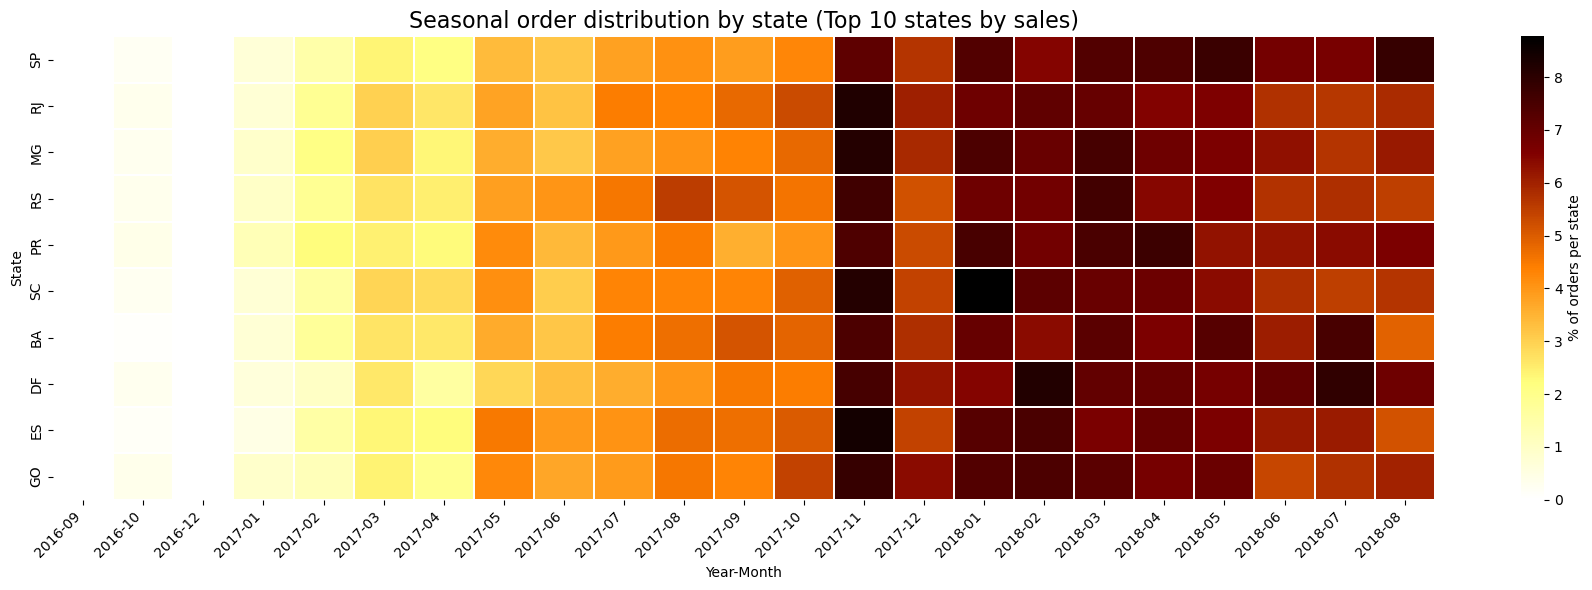

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

# normalizing to 100% for better visualization
pivot_normalized = pivot_top.div(pivot_top.sum(axis=1), axis=0) * 100

plt.figure(figsize=(18, 6))
sns.heatmap(
    pivot_normalized,
    cmap='afmhot_r',
    annot=False,
    linewidths=0.3,
    cbar_kws={'label': '% of orders per state'}
)
plt.title('Seasonal order distribution by state (Top 10 states by sales)', fontsize=16)
plt.xlabel('Year-Month')
plt.ylabel('State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Naturally, we observe a steady increase in sales over time, which can be explained by the organic growth of operations—starting with fewer customers and scaling as the platform became established in the market. However, besides this natural upward trend, there is a massive, specific spike in November driven by Black Friday. This visual acceleration leads us to the following analytical question: Does Black Friday cause a statistically significant increase in sales, or is it merely part of the baseline growth trend?

### Hypothesis Testing via Linear Regression

We can model the sales volume using an Ordinary Least Squares (OLS) linear regression with a time trend and a dummy variable for the month of November, formulated as follows:

$$
\text{sales} = \beta_0 + \beta_1 t + \beta_2 \text{is\_november} + \epsilon
$$

Where:
* $t$ controls for the organic monthly growth trend of the platform.
* $\text{is\_november}$ is our dummy variable (1 for November, 0 for other months).

If the coefficient of the dummy variable ($\beta_2$) is statistically significant, we can conclude that November drives a distinct and relevant shift in sales volume. Thus, we define our hypotheses as:

* **$H_0: \beta_2 \leq 0$** (November decreases or has no effect on sales volume).
* **$H_1: \beta_2 > 0$** (November significantly increases the number of sales).

To prepare our dataset for the regression model, we will aggregate the completed (delivered) sales by year-month and add the time and dummy variables:
1. **Time Trend (`t`):** A sequential index representing the chronological progression of months, allowing the model to capture organic baseline growth.
2. **Black Friday Dummy (`is_november`):** A binary flag set to `1` if the month is November and `0` otherwise, isolating the seasonal promotional impact.

In [133]:
query = """
SELECT
    strftime('%Y', order_purchase_timestamp) AS year,
    strftime('%m', order_purchase_timestamp) AS month,
    COUNT(*) AS total_orders
FROM orders
WHERE order_status = 'delivered'
GROUP BY year, month
ORDER BY year, month;
"""
df_monthly = pd.read_sql_query(query, con)

df_monthly['t'] = range(len(df_monthly))
df_monthly['is_november'] = (df_monthly['month'] == '11').astype(int)

In [134]:
import statsmodels.api as sm

# dependant:
y = df_monthly['total_orders']

# independent:
X = df_monthly[['t', 'is_november']]
# generate intercept
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

# Syntax converted from R via AI assistance
# Original R: model <- lm(total_orders ~ t + is_november, data = df_monthly)

                            OLS Regression Results                            
Dep. Variable:           total_orders   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     99.51
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           4.03e-11
Time:                        15:51:39   Log-Likelihood:                -184.38
No. Observations:                  23   AIC:                             374.8
Df Residuals:                      20   BIC:                             378.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         400.1819    318.009      1.258      

### Regression Model Interpretation & Statistical Insights

Based on the OLS regression results, we can evaluate our hypotheses regarding the impact of Black Friday on sales volume:

1. Statistical Significance & Hypothesis Evaluation
* **The November Impact ($\beta_2$):** The coefficient for `is_november` is **2,534.63** with a p-value of **0.005**. Since the p-value is below our significance level ($\alpha = 0.05$), we **strongly reject the null hypothesis ($H_0$)** and accept the alternative hypothesis ($H_1$). 
* **Conclusion:** This provides definitive statistical proof that the month of November drives a massive, non-random spike in sales, generating an average lift of **~2,535 additional orders** compared to the baseline months.

2. Control Variable & Baseline Trend ($\beta_1$)
* **The Time Trend ($t$):** The variable $t$ is also highly significant ($p < 0.001$) with a coefficient of **334.94**. This indicates that, independent of seasonal spikes, the platform was experiencing an organic baseline growth of approximately **335 additional orders every month**.

3. Model Fit & Explanatory Power
* **Adjusted $R^2$:** The model achieved an **Adjusted $R^2$ of 0.900**. This implies that **90% of the variance** in total monthly orders is explained by just two factors: the chronological progression of time and the seasonal Black Friday effect. This exceptionally high R-squared validates the robustness and predictive strength of our linear model.

#### Business Impact
For an e-commerce operation, these results confirm that Black Friday is a critical revenue driver that completely shifts the operational baseline. The insights suggest that supply chain, inventory, and server capacity planning must be aggressively scaled up specifically for November to absorb a predictable influx of nearly 2,500 extra orders beyond the already rising monthly trend.


## Operational Logistics: Do Stores Strategically Inflate Shipping Deadlines?

With the significant surges in order volume during peak seasons like Black Friday, a critical operational challenge emerges: **fulfillment capacity**. When sales explode, logistics networks face severe bottlenecks. 

In e-commerce, companies often manage this risk by adjusting their delivery estimates. This introduces a classic business dilemma:
1. **Under-promising and over-delivering** protects customer satisfaction (NPS) by ensuring packages arrive "early."
2. However, displaying excessively long delivery windows at checkout might scare potential buyers away, hurting the **sales conversion rate**.

To understand the operational behavior of the stores in this dataset, we will investigate whether shipping deadlines are accurately calibrated or if there is an intentional inflation of estimated delivery times.

### Feature Engineering: Defining the Delivery Gap
To measure this phenomenon, we calculate the difference between when the package was estimated to arrive and when it arrived for each completed delivery:

$$ \text{days\_diff} = \text{Estimated Delivery Date} - \text{Actual Delivery Date} $$

* **$\text{days\_diff} > 0$:** The order arrived earlier than expected (suggesting an inflated estimate/safety buffer).
* **$\text{days\_diff} = 0$:** Perfect punctuality.
* **$\text{days\_diff} < 0$:** The delivery was late (delayed).

Our goal is to statistically verify if the average of this gap is significantly greater than zero.


In [135]:
query = """
SELECT
    order_id,
    julianday(order_estimated_delivery_date) - julianday(order_delivered_customer_date) AS days_diff
FROM orders
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL
  AND order_estimated_delivery_date IS NOT NULL;
"""
df_days_diff = pd.read_sql_query(query, con)
print(df_days_diff.head())

                           order_id  days_diff
0  e481f51cbdc54678b7cc49136f2d6af7   7.107488
1  53cdb2fc8bc7dce0b6741e2150273451   5.355729
2  47770eb9100c2d0c44946d9cf07ec65d  17.245498
3  949d5b44dbf5de918fe9c16f97b45f8a  12.980069
4  ad21c59c0840e6cb83a9ceb5573f8159   9.238171


With the difference in days calculated, we can verify our hypothesis by formulating a right-tailed One-Sample t-Test. We will compare our sample mean against a target value of 0, which represents the scenario where the estimated delivery time and the actual delivery time are equal.

* **$H_0$:** The difference between the estimated and actual delivery dates is less than or equal to 0 (meaning that, on average, the delivery time is correctly estimated or the delivery is late).
* **$H_1$:** The difference is greater than 0 (meaning that, on average, the delivery dates are overestimated).

Due to the large dataset volume, the Central Limit Theorem ensures the robustness of the t-test.


In [136]:
from scipy import stats

days = df_days_diff['days_diff']

t_stat, p_unilateral = stats.ttest_1samp(days, popmean=0, alternative='greater')

print(f"Average days difference: {days.mean()}")
print(f"Median: {days.median()}")
print(f"Standard deviation: {days.std()}")
print(f"t = {t_stat}, p-value (right-tailed) = {p_unilateral:.6f}")


Average days difference: 11.17812572885341
Median: 11.948101851856336
Standard deviation: 10.184353927203757
t = 340.9036458412337, p-value (right-tailed) = 0.000000


The test results show, with overwhelming statistical significance, that the average delivery window is overestimated by 11 days. The probability of this discrepancy occurring by random chance is virtually zero ($p < 0.00001$). 

To visualize the scale of this delivery gap, the chart below displays the distribution of `days_diff`, contrasting our empirical findings against a baseline of perfect punctuality.

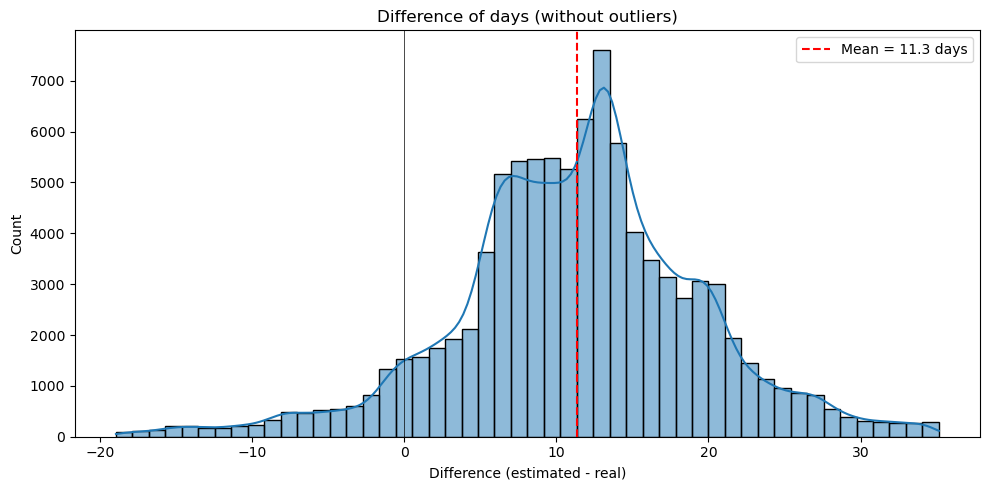

In [137]:
lower = days.quantile(0.01)
upper = days.quantile(0.99)
days_filtered = days[(days >= lower) & (days <= upper)]
plt.figure(figsize=(10,5))
sns.histplot(days_filtered, bins=50, kde=True)
plt.axvline(days_filtered.mean(), color='red', linestyle='--', label=f'Mean = {days_filtered.mean():.1f} days')
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Difference of days (without outliers)')
plt.xlabel('Difference (estimated - real)')
plt.legend()
plt.tight_layout()
plt.show()

As visually evident, the entire distribution is heavily shifted to the right, showing that the vast majority of deliveries arrive long before their official estimated dates.


## Final Project Conclusions & Strategic Takeaways

### 1- Seasonal Sales Impact Verdict
The OLS linear regression model successfully isolated the impact of the platform's organic monthly growth from its seasonal spikes. The model proved with high confidence ($p = 0.005$, $\text{Adjusted } R^2 = 0.90$) that **November**, month of the Black Friday, caused a statistically significant lift of **~2,535 additional orders** beyond the expected baseline. 

### 2- Logistics Hypothesis Verdict
With an average difference of **11 days** and a $p\text{-value} < 0.00001$, we **strongly reject the null hypothesis ($H_0$)**. 

The data proves that e-commerce stores are not poorly calibrated; instead, they operate under a highly aggressive **"Under-Promise and Over-Deliver"** logistics strategy. By adding an artificial cushion of nearly two weeks to the estimated shipping windows, businesses successfully protect customer satisfaction against supply chain volatility, though they accept the trade-off risk of lowering front-end checkout conversion rates.


Note that the insights generated by this project are tied to the historical context of the dataset (2016–2018).
* **Temporal Disconnect:** Given the massive evolution of the Brazilian e-commerce landscape, shifts in macroeconomics, and changes in consumer behavior over the last decade, this model serves as a historical analysis rather than a current predictive tool. 
* **The Coefficient Limit:** The calculated Black Friday lift of **~2,535 orders** is an absolute additive value relative to the platform's volume at that time.



### Final Business Summary
For an e-commerce platform operating in the Brazilian market, the data uncovers a clear operational pattern: while sales naturally scale over time, peak seasons like Black Friday demand aggressive infrastructure pre-planning to handle predictable order spikes. 

Furthermore, the discovery of the 11-day shipping buffer opens a strategic conversation for product and operations managers: could tightening this estimated window by just a few days boost website sales conversion without compromising customer trust?

---
*This project is of my complete independent authorship regarding its business logic, SQL architecture, and statistical methodology, utilizing AI tools as a productivity assistant for code refactoring and documentation translation.*
